In [12]:
from cProfile import label

from mglearn.datasets import load_boston
from sklearn.metrics import accuracy_score

boston=load_boston()

In [13]:
print(boston.keys())

dict_keys(['data', 'target'])


In [14]:
import pandas as pd
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

boston_df=pd.DataFrame(boston.data,columns=feature_names)
boston_df['TARGET']=boston.target
boston_df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,TARGET
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48,22.0


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(boston.data,boston.target,random_state=0)

#OLS linear Regression
lr=LinearRegression()
lr.fit(X_train,y_train)

#learned parameters of the model
print("Slope: ",lr.coef_)
print("Y-intercept: ",lr.intercept_)

Slope:  [-1.17735289e-01  4.40174969e-02 -5.76814314e-03  2.39341594e+00
 -1.55894211e+01  3.76896770e+00 -7.03517828e-03 -1.43495641e+00
  2.40081086e-01 -1.12972810e-02 -9.85546732e-01  8.44443453e-03
 -4.99116797e-01]
Y-intercept:  36.93325545711965


In [16]:
#Accuracy of the model
print("Accuracy of the training set: ",lr.score(X_train,y_train))
print("Accuracy of the testing set: ",lr.score(X_test,y_test))

Accuracy of the training set:  0.7697699488741149
Accuracy of the testing set:  0.6354638433202118


In [17]:
import mglearn
import warnings
warnings.filterwarnings("ignore")
X,y=mglearn.datasets.load_extended_boston()

X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=0)

#OLS linear Regression
lr=LinearRegression()
lr.fit(X_train,y_train)

#Accuracy of the model
print("Accuracy of the training set: ",lr.score(X_train,y_train))
print("Accuracy of the testing set: ",lr.score(X_test,y_test))

Accuracy of the training set:  0.9520519609032727
Accuracy of the testing set:  0.6074721959666014


In [33]:
from sklearn.linear_model import Ridge
rlr = Ridge(alpha=0.3).fit(X_train, y_train)
print(f"Training set accuracy: {rlr.score(X_train, y_train)}")
print(f"Testing set accuracy: {rlr.score(X_test, y_test)}")

Training set accuracy: 0.9136488850790494
Testing set accuracy: 0.7732413227836968


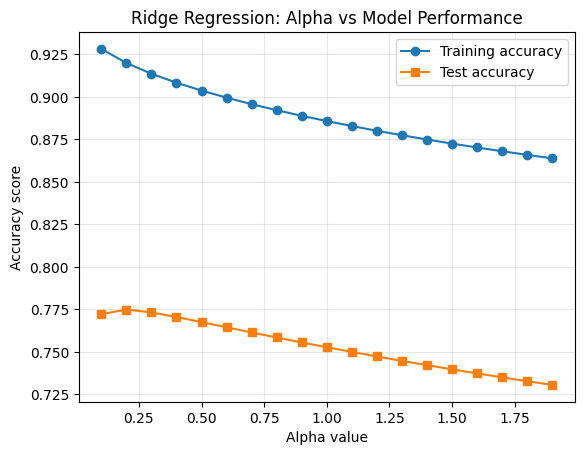

In [40]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import Ridge

# Prepare data structures for storing scores
train_scores = []
test_scores = []
alpha_values = np.arange(0.1, 2, 0.1)  # Start from 0.1 to avoid alpha=0

# Train models with different alpha values
for alpha in alpha_values:
    rlr = Ridge(alpha=alpha).fit(X_train, y_train)
    train_scores.append(rlr.score(X_train, y_train))
    test_scores.append(rlr.score(X_test, y_test))

# Plot results
plt.plot(alpha_values, train_scores, label="Training accuracy", marker='o')
plt.plot(alpha_values, test_scores, label="Test accuracy", marker='s')
plt.xlabel("Alpha value")
plt.ylabel("Accuracy score")
plt.legend()
plt.title("Ridge Regression: Alpha vs Model Performance")
plt.grid(True, alpha=0.3)
plt.show()